# Scenario Financial Analysis

**Notebook 05 in the Curtailed-2-Compute Analysis Workflow**

This notebook performs comprehensive financial analysis for three data center deployment scenarios, calculating Net Present Value (NPV), Internal Rate of Return (IRR), and determining minimum viable rent for target returns.

## Overview

This is the final analysis notebook in the workflow, providing complete financial modeling for:

- **Scenario A**: Metro Baseline (No flexibility, no battery)
- **Scenario B**: Rural Flexible Load (Load shifting capabilities)
- **Scenario C**: Rural with Battery Storage (BESS + load flexibility)

## Workflow Position

- **Input**: 
  - **Electricity Costs**: Annual electricity costs from `04_electricity_costs_analysis.ipynb`:
    - Scenario A: $19.97M (baseline, retrofitted, 67% utilization)
    - Scenario B: $18.04M (flexible load, 100% utilization, LMP pricing during curtailment)
    - Scenario C: $17.90M (flexible load + BESS, includes battery revenue)
  - **CapEx/OpEx Data**: Sourced from paper Tables 6 & 7 (see scenario configurations)
- **Output**: Comprehensive financial metrics, scenario comparisons, and minimum viable rent calculations

## Key Features

### Core Financial Functions
- **NPV Calculation**: Net Present Value with robust discounting
- **IRR Calculation**: Internal Rate of Return with fallback methods (numpy_financial → bisection → MIRR)
- **MIRR Calculation**: Modified IRR using explicit finance and reinvestment rates
- **Payback Period**: Discounted payback period calculation

### Model Engine Components
- **Revenue Building**: Multi-component revenue model (base rent, services, BESS revenue)
- **OPEX Modeling**: Operating expense projections with escalation
- **Lease-up Curves**: Utilization ramp-up modeling for new facilities

### Feasibility Analysis
- **Bankability Screening**: Evaluates projects against target IRR (15%)
- **Rent Solver**: Finds minimum viable rent required for target returns
- **Scenario Comparison**: Side-by-side financial performance comparison

## Financial Metrics

- Net Present Value (NPV)
- Internal Rate of Return (IRR) with robust fallback
- Modified Internal Rate of Return (MIRR)
- Total Cost of Ownership (TCO)
- Discounted Payback Period
- Minimum Viable Rent for 15% IRR

## Methodology

### Financial Modeling Approach
- **Time Horizon**: 25 years (standard commercial real estate hold period)
- **Discount Rate**: 8% (hurdle rate for NPV calculations, represents cost of capital)
- **Target IRR**: 15% (levered IRR for equity investors, industry standard for data center investments)
- **Robust IRR**: Uses fallback hierarchy (numpy_financial → bisection → MIRR) for reliable calculations

### Cash Flow Timing Conventions
- **t=0**: Initial investment (CapEx, net of incentives)
- **t=1 to t=25**: Annual Net Operating Income (NOI = Revenue - Non-power OpEx)
- **t=25**: Terminal value added to final year NOI
- **Note**: Power costs (electricity) are excluded from NOI as they are pass-through expenses paid by tenants

### Levered vs. Unlevered Analysis
- **Unlevered**: All-cash investment analysis (no debt)
- **Levered**: Debt-financed investment analysis (55% LTV, 7.5% interest rate)
  - Interest-only period: 2-3 years (aligned with lease-up)
  - Amortization: Remaining term after I-O period
  - DSCR (Debt Service Coverage Ratio): NOI / Debt Service (must meet ramp covenants)

### Bankability Criteria
- **IRR**: Levered IRR ≥ 15% (target return for equity investors)
- **DSCR Ramp**: Year 1 ≥ 1.00x, Year 2 ≥ 1.15x, Year 3+ ≥ 1.30x (lender covenants)
- **Steady-State Yield**: Final year NOI / Effective CapEx ≥ 9% (minimum return threshold)

## Outputs

- Financial performance metrics for each scenario
- Required rent levels to achieve target IRR
- Scenario comparison tables
- Visualization plots

## Reproducibility Notes

**Important**: This notebook depends on electricity cost outputs from `04_electricity_costs_analysis.ipynb`. 
To reproduce results:
1. Run notebooks 01-04 in sequence to generate electricity cost values
2. Ensure electricity cost values match those documented in the scenario configurations
3. If electricity costs change, update the `opex_y1` calculations in `SCENARIO_CONFIGS`

**Data Sources**:
- Electricity costs: Calculated in `04_electricity_costs_analysis.ipynb` using CAISO LMP data
- CapEx/Total OpEx: From paper Tables 6 & 7 (referenced in code comments)
- Financial assumptions: Industry-standard values for data center investments



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Prefer numpy_financial if present
try:
    import numpy_financial as npf
except Exception:
    npf = None
    print("Warning: numpy_financial not found. Using numpy.irr (deprecated).")

# --- Core Financial Functions ---

def pmt(rate, nper, pv):
    """
    Calculates the fixed periodic payment (annuity) for a loan.
    
    Logic:
    - Implements the standard loan amortization formula:
      Payment = PV * [r(1+r)^n] / [(1+r)^n - 1]
    - Includes an edge case for rate = 0, where payment is simply PV / nper.
    """
    if rate == 0:
        return pv / nper
    return pv * (rate * (1 + rate)**nper) / ((1 + rate)**nper - 1)

def npv(rate, cf):
    """
    Calculates the Net Present Value (NPV) of a cash flow series.
    
    Logic:
    - Sums all cash flows discounted to their present value.
    - Assumes the first cash flow (cf[0]) is at t=0 and is undiscounted.
    - Formula: sum(c_t / (1 + rate)**t) for t = 0 to N.
    """
    return sum(c / (1 + rate)**t for t, c in enumerate(cf))

def mirr(cf, finance_rate=0.07, reinvest_rate=0.08):
    """
    Calculates the Modified Internal Rate of Return (MIRR).
    
    Logic:
    - Solves a key flaw in IRR by using explicit, different rates for
      financing (borrowing) and reinvestment (earning).
    1. Separates all cash flows into positive (inflows) and negative (outflows).
    2. Calculates the Future Value (FV) of all inflows at the `reinvest_rate`.
    3. Calculates the Present Value (PV) of all outflows at the `finance_rate`.
    4. Returns the rate that equates the PV of outflows to the FV of inflows,
       spread over the project's life (T).
    """
    pos = [(t,c) for t,c in enumerate(cf) if c > 0]
    neg = [(t,c) for t,c in enumerate(cf) if c < 0]
    if not pos or not neg:
        return np.nan
    T = len(cf) - 1
    fv_pos = sum(c * (1 + reinvest_rate)**(T - t) for t, c in pos)
    pv_neg = -sum(c / (1 + finance_rate)**t for t, c in neg)
    if pv_neg <= 0:
        return np.nan
    return (fv_pos / pv_neg)**(1 / T) - 1

def irr_bisect(cf, low=-0.99, high=3.0, tol=1e-7, iters=200):
    """
    Finds the Internal Rate of Return (IRR) using a numerical bisection
    (binary search) algorithm.
    
    Logic:
    - The IRR is the discount rate at which NPV(rate, cf) = 0.
    1. Checks that a root is possible (must have both positive and negative CFs).
    2. Establishes a [low, high] bracket where NPV(low) and NPV(high) have
       opposite signs (meaning a root *must* exist between them).
    3. Iteratively narrows this bracket by checking the NPV at the midpoint
       until the NPV is within a tiny tolerance (tol) of zero.
    """
    if not (any(c < 0 for c in cf) and any(c > 0 for c in cf)):
        return np.nan
    a, b = low, high
    fa, fb = npv(a, cf), npv(b, cf)
    expand = 0
    # Expands bracket if initial guess is poor
    while fa * fb > 0 and expand < 6:
        b = b * 2 + 0.5
        fb = npv(b, cf)
        expand += 1
    if fa * fb > 0:
        return np.nan
    # Bisection search
    for _ in range(iters):
        m = 0.5 * (a + b)
        fm = npv(m, cf)
        if abs(fm) < tol:
            return m
        if fa * fm < 0:
            b, fb = m, fm
        else:
            a, fa = m, fm
    return m

def irr_robust(cf, finance_rate=0.07, reinvest_rate=0.08):
    """
    Calculates a project's rate of return using a robust fallback hierarchy
    to ensure a stable, useful value is always returned.
    
    Logic:
    1. [Try 1] Use `numpy_financial.irr`. This is the fast, C-optimized
       standard. It's the best-case scenario.
    2. [Try 2] If `npf.irr` fails (e.g., convergence error, multiple roots),
       fall back to the `irr_bisect` function. This is a slower but very
       stable numerical solver.
    3. [Try 3] If `irr_bisect` fails (e.g., no single IRR root exists),
       fall back to `mirr`. MIRR is a different but related metric that
       is guaranteed to have a single solution and is a defensible
       measure of project return.
    """
    cf = list(cf)
    if len(cf) < 2: return (np.nan, "nan")
    if cf[0] >= 0: cf[0] -= 1e-6  # Ensure negative start (investment)
    
    # Try 1: numpy_financial (fast, standard)
    if npf is not None:
        try:
            v = npf.irr(cf)
            if v is not None and np.isfinite(v): return (float(v), "npf.irr")
        except Exception:
            pass
    
    # Try 2: Bisection (slower, stable)
    v = irr_bisect(cf)
    if v is not None and np.isfinite(v): return (float(v), "bisect")
    
    # Try 3: MIRR (different logic, but guaranteed solution)
    v = mirr(cf, finance_rate=finance_rate, reinvest_rate=reinvest_rate)
    if v is not None and np.isfinite(v): return (float(v), "mirr")
    
    return (np.nan, "nan")

print("Cell 1: Core financial functions defined.")

Cell 1: Core financial functions defined.


In [2]:
# --- Model Engine Components ---

def lease_up(initial_u, target_u, years_to_target, T):
    """
    Builds the utilization (occupancy) curve for the project.

    Logic:
    - This function models the real-world ramp-up of a new data center.
    1. It creates a linear ramp (`np.linspace`) from the starting
       `initial_utilization` (e.g., 25%) to the stabilized
       `target_utilization` (e.g., 85%).
    2. This ramp occurs over the specified `years_to_target` (e.g., 3 years).
    3. It then appends a "tail" of the constant `target_utilization`
       for all remaining years of the project.
    4. Finally, it ensures the total curve is the correct length (T).
    """
    ramp = np.linspace(initial_u, target_u, max(1, years_to_target))
    tail = np.full(max(0, T - years_to_target), target_u)
    return np.concatenate([ramp, tail])[:T]

def build_revenue(
    scale_mw, base_rent_per_mw_y1, util_curve, rent_escalator, 
    service_pct=0.08, renewables_uplift=0.00, bess_y1=0.0, bess_esc=0.0
):
    """
    Builds the full, multi-component annual revenue series.

    Logic:
    - This is a "stacked" revenue model, common in real estate finance.
    1. **Base Rent:** Calculates the potential rent at 100% occupancy
       (`base_full`) and applies the `util_curve` to get the actual
       utilized rent. This is then "escalated" each year by the
       `rent_escalator` and any `renewables_uplift` premium.
    2. **Service Revenue:** Adds revenue from managed services, calculated
       as a simple percentage (`service_pct`) of the base rent.
    3. **BESS Revenue:** Adds a separate, independent revenue stream
       from the battery system, which has its own starting revenue
       (`bess_y1`) and escalator (`bess_esc`).
    4. Returns the sum of all three components for each year.
    """
    T = len(util_curve)
    rent_escal = (1 + rent_escalator)**np.arange(T)
    base_full = base_rent_per_mw_y1 * scale_mw
    base_series = base_full * util_curve * rent_escal * (1 + renewables_uplift)
    service_series = base_series * service_pct
    bess_series = np.array([bess_y1 * (1 + bess_esc)**t for t in range(T)])
    total = base_series + service_series + bess_series
    return total

def build_opex(opex_y1, opex_escalator, T):
    """
    Builds the non-power operating expense series.

    Logic:
    - Models the annual operating costs (e.g., staffing, maintenance,
      property taxes) based on a Year 1 baseline (`opex_y1`).
    - This baseline cost is then grown each year by the `opex_escalator`
      (inflation rate) using a standard compound growth formula.
    - Note: This model correctly excludes power, which is treated as a
      pass-through cost in the provided paper.
    """
    opex_escal = (1 + opex_escalator)**np.arange(T)
    return opex_y1 * opex_escal

def debt_service_series(net_capex, debt_ratio, debt_rate, term_years, io_years):
    """
    Calculates the key figures for the project's loan.

    Logic:
    1. **Debt:** Calculates the total loan principal (`debt`) based on the
       `net_capex` and the `debt_ratio` (Loan-to-Cost).
    2. **I-O Payment:** Calculates the smaller, "interest-only" payment
       (`io_pay`) made during the initial `io_years`.
    3. **Amortizing Payment:** Calculates the larger, "principal + interest"
       payment (`amort_pay`) using the `pmt` function. This payment
       is calculated for the remaining term of the loan after the
       I-O period ends.
    """
    debt = net_capex * debt_ratio
    io_pay = debt * debt_rate
    amort_years = max(1, term_years - io_years)
    amort_pay = pmt(debt_rate, amort_years, debt)
    return debt, io_pay, amort_pay

def run_model(cfg):
    """
    Runs the full data center financial model based on a configuration dictionary.

    Logic:
    - This function ties all helper components together to build the
      unlevered (all-cash) and levered (with-debt) cash flow models.
    
    1.  **Setup:** Unpacks config, calculates `eff_capex` (net of incentives).
    2.  **NOI:** Builds the `util` curve, `rev` series, and `opex` series.
        Calculates Net Operating Income (NOI) as `rev - opex`.
    3.  **Terminal Value (TV):** Calculates the project's "exit price" or
        "sale price" at the end of the 25-year hold. This is a standard
        real estate valuation, calculated as a multiple of the final
        year's NOI (`noi[-1] * terminal_multiple`).
    
    4.  **Unlevered Model (All-Cash):**
        - Builds a cash flow series: `[-eff_capex, noi_y1, ... noi_y25 + tv]`.
        - Calculates `unlevered_npv` by discounting this series at the
          `discount_rate`.
        - Calculates `unlevered_irr` using the `irr_robust` function.
    
    5.  **Levered Model (With-Debt):**
        - Calculates debt figures using `debt_service_series`.
        - Builds the Equity Cash Flow (`eq_cf`) series:
          - t=0: `[- (eff_capex - debt)]` (the "down payment" or equity).
          - t=1..T: `noi[t] - debt_service[t]` (NOI minus the loan payment).
          - t=T: Adds the `tv` to the final year's cash flow.
        - Calculates `levered_irr` and `levered_npv` from this `eq_cf` series.
        - Also calculates the DSCR (`noi / debt_service`) for each year.
    
    6.  **Output:** Returns a dictionary of all key metrics and time series.
    """
    # Unpack basic parameters
    T    = cfg["years"]
    MW   = cfg["scale_mw"]
    
    # CapEx
    eff_capex = cfg["total_capex"] * (1 - cfg.get("capex_incentive_pct", 0.0))
    
    # Utilization
    util = lease_up(cfg["initial_utilization"], cfg["target_utilization"], cfg["lease_up_years"], T)
    
    # Revenue
    rev = build_revenue(
        MW, cfg["base_rent_per_mw_y1"], util, cfg["rent_escalator"],
        service_pct=cfg["service_revenue_pct"],
        renewables_uplift=cfg.get("renewables_uplift_pct", 0.0),
        bess_y1=cfg.get("bess_revenue_y1", 0.0),
        bess_esc=cfg.get("bess_revenue_escalator", 0.0),
    )
    
    # OpEx (Note: opex_y1 is non-power only)
    # Power costs (electricity) are excluded because they are pass-through expenses
    # paid directly by tenants. Only non-power OpEx (staffing, maintenance, 
    # property taxes) is included in NOI calculation.
    opex = build_opex(cfg["opex_y1"], cfg["opex_escalator"], T)
    noi = rev - opex
    
    # Terminal Value
    tv = noi[-1] * cfg["terminal_multiple"]

    # Unlevered
    disc = (1 + cfg["discount_rate"])**np.arange(1, T + 1)
    unlev_cf = noi.copy()
    unlevered_npv = -eff_capex + (unlev_cf / disc).sum() + tv / ((1 + cfg["discount_rate"])**T)
    unlev_series = [-eff_capex] + list(unlev_cf[:-1]) + [unlev_cf[-1] + tv]
    unlevered_irr, _ = irr_robust(unlev_series, finance_rate=cfg["debt_rate"], reinvest_rate=cfg["discount_rate"])

    # Debt Service
    debt, io_pay, amort_pay = debt_service_series(
        eff_capex, cfg["debt_ratio"], cfg["debt_rate"], cfg["debt_term_years"], cfg["io_years"]
    )

    # Levered
    eq_cf = [- (eff_capex - debt)]
    dscr = []
    for t in range(T):
        ds = io_pay if t < cfg["io_years"] else amort_pay
        dscr.append(noi[t] / ds if ds > 0 else np.inf)
        eq_cf.append(noi[t] - ds)
    eq_cf[-1] += tv  # Add terminal value

    levered_irr, lev_method = irr_robust(eq_cf, finance_rate=cfg["debt_rate"], reinvest_rate=cfg["discount_rate"])
    levered_npv = (np.array(eq_cf[1:]) / disc).sum() + eq_cf[0] # Note: eq_cf[0] is already negative

    return dict(
        unlevered_npv=unlevered_npv,
        unlevered_irr=unlevered_irr,
        levered_npv=levered_npv,
        levered_irr=levered_irr,
        irr_method=lev_method,
        min_dscr=float(np.min(dscr)),
        avg_dscr=float(np.mean(dscr)),
        steady_state_yield=float(noi[-1] / eff_capex),
        series=dict(util=util, rev=rev, opex=opex, noi=noi, dscr=np.array(dscr)),
        debug=dict(equity_cf=eq_cf, unlev_cf=unlev_series),
    )

print("Cell 2: Core model engine 'run_model' defined.")

Cell 2: Core model engine 'run_model' defined.


In [3]:
# --- Base Assumptions (Shared across all scenarios) ---
BASE_PARAMS = dict(
    scale_mw=20.0, 
    years=25,
    debt_term_years=25,
    discount_rate=0.08,
    rent_escalator=0.025,  # Conservative rent growth
    opex_escalator=0.03,    # Conservative opex growth
)

# --- Solver Targets (Bankability Screens) ---
TARGET_IRR = 0.15     # Target Levered IRR
IRR_TOL = 0.0025      # +/- 25 bps tolerance
DSCR_RAMP = (1.00, 1.15, 1.30) # Min DSCR for Year 1, Year 2, Year 3+
MIN_YIELD = 0.09      # Min steady-state NOI / Effective CapEx

# --- Scenario-Specific Fixed Parameters ---
# CapEx and OpEx data sourced from paper Table 6 & 7
# 
# IMPORTANT: Electricity costs (power OpEx) are sourced from notebook 04:
#   - Scenario A: $19.97M (from 04_electricity_costs_analysis.ipynb)
#   - Scenario B: $18.04M (from 04_electricity_costs_analysis.ipynb)
#   - Scenario C: $17.90M (from 04_electricity_costs_analysis.ipynb)
#
# Non-power OpEx is calculated as: Total OpEx - Electricity Cost
# This separation is critical because:
#   1. Power costs are pass-through expenses (tenant pays directly)
#   2. Non-power OpEx (staffing, maintenance, property taxes) is owner's responsibility
#   3. Financial modeling requires separation for accurate NOI calculation
SCENARIO_CONFIGS = {
    "A_Metro": {
        "total_capex": 278_000_000,
        # Total OpEx Y1: $29.0M (from paper Table 6/7)
        # Electricity Cost: $19.97M (from notebook 04, Scenario A)
        # Non-power OpEx: $29.0M - $19.97M = $9.03M
        "opex_y1":     29_000_000 - 19_970_000,  # = 9.03M (Non-power)
        "initial_utilization": 0.7, # Stronger pre-leasing in hot market 
        "target_utilization": 0.85,
        "lease_up_years": 2, # Faster ramp-up (2 years)
        "service_revenue_pct": 0.08,
        "capex_incentive_pct": 0.00, # No incentives in mature market
        "renewables_uplift_pct": 0.00,
        "terminal_multiple": 10.0, # Premium for metro location
        "debt_ratio": 0.55,
        "debt_rate": 0.075,
        "io_years": 2, # Aligned with 2-year lease-up
        "bess_revenue_y1": 0.0,
        "bess_revenue_escalator": 0.0,
    },
    "B_Rural_Flex": {
        "total_capex": 183_500_000, # Using 183.5M from Table 7
        # Total OpEx Y1: $25.9M (from paper Table 6/7)
        # Electricity Cost: $18.04M (from notebook 04, Scenario B)
        # Non-power OpEx: $25.9M - $18.04M = $7.86M
        "opex_y1":     25_900_000 - 18_040_000,  # = 7.86M (Non-power)
        "initial_utilization": 0.30, # Slower start in new market
        "target_utilization": 0.85,
        "lease_up_years": 3,
        "service_revenue_pct": 0.00, # No interconnection revenue
        "capex_incentive_pct": 0.05, # 5% incentive (e.g., tax abatement)
        "renewables_uplift_pct": 0.02,
        "terminal_multiple": 8.5, # Standard multiple for rural asset
        "debt_ratio": 0.55,
        "debt_rate": 0.075,
        "io_years": 3, # Aligned with 3-year lease-up
        "bess_revenue_y1": 0.0,
        "bess_revenue_escalator": 0.0,
    },
    "C_Rural_Flex_BESS": {
        # CapEx reflects $195.5M (T7) minus 30% ITC on $12M BESS (T4)
        "total_capex": 195_500_000 - 3_600_000, # = $191,900,000
        # Total OpEx Y1: $26.7M (from paper Table 6/7)
        # Electricity Cost: $17.90M (from notebook 04, Scenario C)
        #   Note: Scenario C electricity cost is NET (after battery revenue)
        # Non-power OpEx: $26.7M - $17.90M = $8.80M
        "opex_y1":     26_700_000 - 17_900_000,  # = 8.80M (Non-power)
        "initial_utilization": 0.30, # Slower start in new market
        "target_utilization": 0.85,
        "lease_up_years": 3,
        "service_revenue_pct": 0.00, # No interconnection revenue
        "capex_incentive_pct": 0.00, # Incentive is baked into CapEx (ITC)
        "renewables_uplift_pct": 0.02,
        "terminal_multiple": 8.5, # Standard multiple for rural asset
        "debt_ratio": 0.55,
        "debt_rate": 0.075,
        "io_years": 3, # Aligned with 3-year lease-up
        "bess_revenue_y1": 140_000, # CONSERVATIVE: No ancillary revenue modeled
        "bess_revenue_escalator": 0.0,
    },
}

# Brackets for the rent-seeking solver
RENT_BRACKETS = {
    "A_Metro": (2_000_000, 5_000_000),
    "B_Rural_Flex": (2_000_000, 5_000_000),
    "C_Rural_Flex_BESS": (2_000_000, 5_000_000),
}

print("Cell 3: Most Defensible Scenario Configurations Loaded.")
print(f"  Scenario A: {SCENARIO_CONFIGS['A_Metro']['initial_utilization']*100:.0f}% -> 85% in {SCENARIO_CONFIGS['A_Metro']['lease_up_years']} years")
print(f"  Scenario B: {SCENARIO_CONFIGS['B_Rural_Flex']['initial_utilization']*100:.0f}% -> 85% in {SCENARIO_CONFIGS['B_Rural_Flex']['lease_up_years']} years")
print(f"  Scenario C: {SCENARIO_CONFIGS['C_Rural_Flex_BESS']['initial_utilization']*100:.0f}% -> 85% in {SCENARIO_CONFIGS['C_Rural_Flex_BESS']['lease_up_years']} years")
print(f"  Scenario C CapEx (Net ITC): ${SCENARIO_CONFIGS['C_Rural_Flex_BESS']['total_capex']:,.0f}")
print(f"  Scenario C BESS Revenue (Y1): ${SCENARIO_CONFIGS['C_Rural_Flex_BESS']['bess_revenue_y1']:,.0f}")

Cell 3: Most Defensible Scenario Configurations Loaded.
  Scenario A: 70% -> 85% in 2 years
  Scenario B: 30% -> 85% in 3 years
  Scenario C: 30% -> 85% in 3 years
  Scenario C CapEx (Net ITC): $191,900,000
  Scenario C BESS Revenue (Y1): $140,000


In [4]:
# --- Feasibility Check Functions ---

def ramp_dscr_ok(dscr_series, ramp=DSCR_RAMP):
    """
    Checks if a DSCR series passes a tiered, ramp-up threshold.
    
    Logic:
    - This function models a typical bank loan covenant for a new project.
      Lenders understand revenue will be low during lease-up, so they
      allow lower DSCRs in the first few years.
    1. Unpacks the `ramp` tuple (e.g., (1.00, 1.15, 1.30)) into:
       - `a`: Year 1 minimum DSCR
       - `b`: Year 2 minimum DSCR
       - `c`: Year 3+ (stabilized) minimum DSCR
    2. Checks if the `dscr_series[0]` (Year 1) is >= `a`.
    3. Checks if the `dscr_series[1]` (Year 2) is >= `b`.
    4. Checks if the *minimum* of all subsequent years (`dscr_series[2:]`)
       is >= `c`. This is a critical check to ensure the project
       never violates its covenant after stabilization.
    """
    a, b, c = ramp
    if len(dscr_series) < 3: 
        return False
    return (dscr_series[0] >= a) and (dscr_series[1] >= b) and (float(np.min(dscr_series[2:])) >= c)

def meets_bankability(res):
    """
    Acts as a master "pass/fail" check for a given model result.
    
    Logic:
    - A project is "bankable" if it satisfies both the equity investors
      and the debt lenders.
    - This function combines three critical checks:
      1. `np.isfinite(res['levered_irr'])`: Is the IRR a valid number?
      2. `res['steady_state_yield'] >= MIN_YIELD`: Does the project's
         stabilized return meet the equity partner's minimum threshold?
      3. `ramp_dscr_ok(...)`: Does the project's cash flow meet the
         lender's DSCR covenants at all times?
    - All three must be True for the project to be considered viable.
    """
    return (
        (np.isfinite(res['levered_irr'])) and
        (res['steady_state_yield'] >= MIN_YIELD) and
        ramp_dscr_ok(res['series']['dscr'], DSCR_RAMP)
    )

# --- Rent Solver Function ---

def find_min_rent_for_target_irr(scenario_name, nonrent_params, target=TARGET_IRR, tol=IRR_TOL, max_iter=30):
    """
    Uses a bisection (binary search) algorithm to find the *minimum*
    `base_rent_per_mw_y1` that achieves the target IRR *while also*
    passing all bankability screens.
    
    Logic:
    1.  Sets a [low, high] bracket of possible rents to search within.
    2.  **Crucial Pre-Check:** It first runs the model with the *highest*
        rent (`hi`). If even this rent fails to meet the bankability
        screens (e.g., the DSCR ramp), the function gives up immediately,
        as no lower rent could possibly work.
    3.  **Bisection Loop:**
        a.  Calculates the `mid_rent` in the middle of the current bracket.
        b.  Runs the full `run_model` with this `mid_rent`.
        c.  **Checks for Success:** A `mid_rent` is a "success" if it
            meets *two* conditions:
            i.   The `levered_irr` is >= the `target` IRR.
            ii.  The *entire result* passes the `meets_bankability`
                 check (meaning DSCR and Yield are also OK).
    4.  **Narrows the Bracket:**
        -   **If (Success):** This is a valid, working rent. The function saves
            it as `best_solution` and sets `hi = mid_rent`. This is the
            key to *minimization*—it now searches the *lower half* of
            the bracket to find an even cheaper rent that still works.
        -   **If (Failure):** The rent is too low. The function sets
            `lo = mid_rent` and searches the *upper half* of the bracket.
    5.  The loop repeats until the bracket is negligibly small (`< $1000`).
    """
    lo, hi = RENT_BRACKETS[scenario_name]
    best_solution = None

    # Check if the upper bound is even feasible
    cfg_hi = {**BASE_PARAMS, **nonrent_params, "base_rent_per_mw_y1": hi}
    res_hi = run_model(cfg_hi)
    if (not meets_bankability(res_hi)) or (res_hi["levered_irr"] < target - tol):
        print(f"Warning: Scenario {scenario_name} is infeasible even at max rent ${hi:,.0f}/MW.")
        return None  # Can't hit target with this combo

    # Bisection search
    for _ in range(max_iter):
        mid_rent = 0.5 * (lo + hi)
        cfg_mid = {**BASE_PARAMS, **nonrent_params, "base_rent_per_mw_y1": mid_rent}
        res_mid = run_model(cfg_mid)

        if (np.isfinite(res_mid["levered_irr"]) and 
            (res_mid["levered_irr"] >= target - tol) and 
            meets_bankability(res_mid)):
            
            best_solution = (mid_rent, res_mid) # This is a valid solution
            hi = mid_rent # Try to find a lower rent
        else:
            lo = mid_rent # Rent is too low, must increase

        if abs(hi - lo) < 1000:  # Stop when rent is within $1k resolution
            break
            
    return best_solution # (rent, result_dict) or None

print("Cell 4: Feasibility and solver functions defined.")

Cell 4: Feasibility and solver functions defined.


Step 1: Running baseline analysis to find minimum viable rent for ~15% IRR...

--- Solving for Scenario: A_Metro ---

--- Solving for Scenario: B_Rural_Flex ---

--- Solving for Scenario: C_Rural_Flex_BESS ---


   Step 1: Minimum Viable Rent to Achieve ~15% Levered IRR


,Min Viable Rent ($/MW-yr),Levered IRR,Steady-State Yield,Min DSCR (Y1),Min DSCR (Y3+),CapEx ($M),"Non-Power OpEx (Y1, $M)"
Scenario,,,,,,,
A_Metro,"$2,000,732",15.32%,17.30%,1.85x,2.05x,$278.0M,$9.03M
B_Rural_Flex,"$2,459,961",27.76%,35.09%,1.00x,4.14x,$183.5M,$7.86M
C_Rural_Flex_BESS,"$2,708,984",27.75%,35.03%,1.00x,4.14x,$191.9M,$8.80M




   Step 1: Baseline Scenario Financial Plots


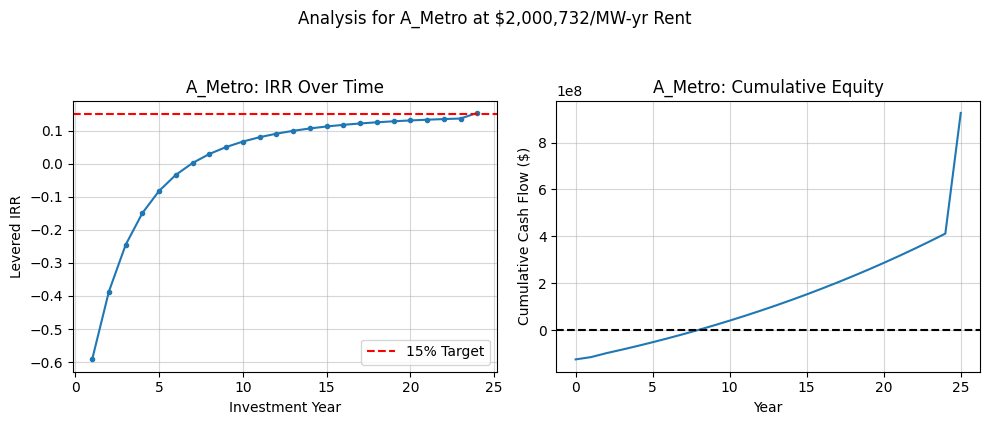

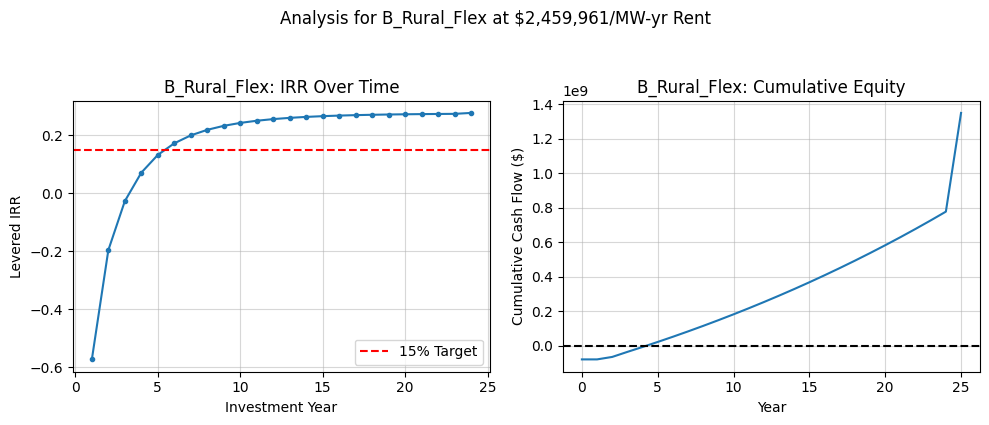

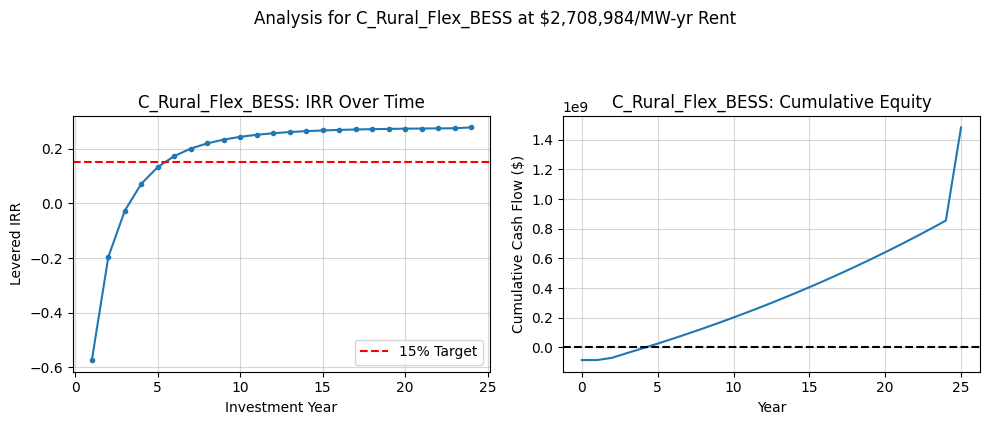

In [5]:
# --- Plotting Functions (for this cell) ---
def plot_scenario_results(scenario_name, rent, results):
    """Generates the two required plots for a solved scenario."""
    
    # 1. Rolling IRR Plot
    eq_cf = results["debug"]["equity_cf"]
    irrs = []
    _irr_func = npf.irr if npf else irr_bisect
    
    for t in range(2, len(eq_cf)): # Start from year 1 (index 2)
        seg = eq_cf[:t+1]
        try:
            val = _irr_func(seg)
        except Exception:
            val = np.nan
        irrs.append(val)
        
    x_irr = np.arange(1, len(irrs) + 1)
    
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(x_irr, irrs, marker='o', markersize=3)
    plt.axhline(y=TARGET_IRR, color='r', linestyle='--', label=f"{TARGET_IRR:.0%} Target")
    plt.title(f"{scenario_name}: IRR Over Time")
    plt.xlabel("Investment Year")
    plt.ylabel("Levered IRR")
    plt.grid(True, alpha=0.5)
    plt.legend()

    # 2. Cumulative Equity Cash Flow Plot
    cum_eq_cf = np.cumsum(eq_cf)
    x_cum = np.arange(len(cum_eq_cf))
    
    plt.subplot(1, 2, 2)
    plt.plot(x_cum, cum_eq_cf)
    plt.axhline(y=0, color='k', linestyle='--')
    plt.title(f"{scenario_name}: Cumulative Equity")
    plt.xlabel("Year")
    plt.ylabel("Cumulative Cash Flow ($)")
    plt.grid(True, alpha=0.5)
    
    plt.suptitle(f"Analysis for {scenario_name} at ${rent:,.0f}/MW-yr Rent", y=1.05)
    plt.tight_layout()
    plt.show()

# --- Run Baseline Analysis ---
print("Step 1: Running baseline analysis to find minimum viable rent for ~15% IRR...")

summary_rows = []
all_results = {}

for scenario_name, config in SCENARIO_CONFIGS.items():
    print(f"\n--- Solving for Scenario: {scenario_name} ---")
    
    # Find the minimum rent that hits the 15% target
    solution = find_min_rent_for_target_irr(scenario_name, config, target=TARGET_IRR)
    
    if solution:
        rent, res = solution
        all_results[scenario_name] = (rent, res) # Save for plotting
        
        summary_rows.append({
            "Scenario": scenario_name,
            "Min Viable Rent ($/MW-yr)": rent,
            "Levered IRR": res["levered_irr"],
            "Steady-State Yield": res["steady_state_yield"],
            "Min DSCR (Y1)": res["series"]["dscr"][0],
            "Min DSCR (Y3+)": np.min(res["series"]["dscr"][2:]),
            "CapEx ($M)": config["total_capex"] / 1_000_000,
            "Non-Power OpEx (Y1, $M)": config["opex_y1"] / 1_000_000,
        })
    else:
        print(f"FAILED: No solution found for {scenario_name} that meets all criteria.")

# --- Display Summary Table ---
print("\n\n" + "="*50)
print(f"   Step 1: Minimum Viable Rent to Achieve ~{TARGET_IRR:.0%} Levered IRR")
print("="*50)

if summary_rows:
    baseline_summary_df = pd.DataFrame(summary_rows)
    display(baseline_summary_df.set_index("Scenario").style.format({
        "Min Viable Rent ($/MW-yr)": "${:,.0f}",
        "Levered IRR": "{:.2%}",
        "Steady-State Yield": "{:.2%}",
        "Min DSCR (Y1)": "{:.2f}x",
        "Min DSCR (Y3+)": "{:.2f}x",
        "CapEx ($M)": "${:.1f}M",
        "Non-Power OpEx (Y1, $M)": "${:.2f}M",
    }))
else:
    print("No feasible solutions were found for any scenario.")

# --- Generate Plots ---
print("\n\n" + "="*50)
print("   Step 1: Baseline Scenario Financial Plots")
print("="*50)
if all_results:
    for scenario_name, (rent, res) in all_results.items():
        plot_scenario_results(scenario_name, rent, res)
else:
    print("No plots to generate as no solutions were found.")


   Step 2: Defining IRR Sweep Analysis
Running IRR sweeps for all scenarios...
  Sweeping A_Metro...
  Sweeping B_Rural_Flex...
  Sweeping C_Rural_Flex_BESS...
Sweep complete. Plotting results...


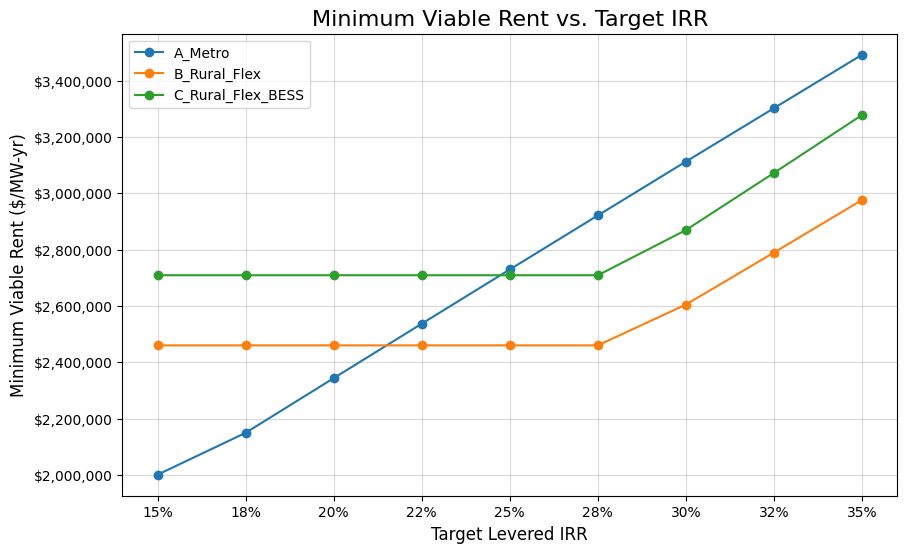


Full Sweep Data:


,Scenario,Target IRR,Solved Min Rent,Resulting IRR
0,A_Metro,0.150,2.000732e+06,0.153238
1,A_Metro,0.175,2.149414e+06,0.172514
2,A_Metro,0.200,2.343506e+06,0.197558
3,A_Metro,0.225,2.536865e+06,0.222534
4,A_Metro,0.250,2.729492e+06,0.247522
5,A_Metro,0.275,2.921387e+06,0.272544
6,A_Metro,0.300,3.112549e+06,0.297589
7,A_Metro,0.325,3.302246e+06,0.322536
8,A_Metro,0.350,3.491943e+06,0.347548
9,B_Rural_Flex,0.150,2.459961e+06,0.277585


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

print("\n" + "="*50)
print("   Step 2: Defining IRR Sweep Analysis")
print("="*50)

def run_irr_sweep_analysis():
    # Define the IRR targets we want to test
    irr_targets = np.linspace(0.15, 0.35, 9) # Sweep from 15% to 35% in 9 steps
    results = []

    print("Running IRR sweeps for all scenarios...")
    
    # Loop through each scenario
    for scenario_name, config in SCENARIO_CONFIGS.items():
        print(f"  Sweeping {scenario_name}...")
        # Loop through each target IRR
        for target_irr in irr_targets:
            # Find the min rent for *this* target IRR
            solution = find_min_rent_for_target_irr(scenario_name, config, target=target_irr)
            
            rent_solution = None
            irr_solution = None
            
            if solution:
                rent, res = solution
                rent_solution = rent
                irr_solution = res['levered_irr']
            
            results.append({
                "Scenario": scenario_name,
                "Target IRR": target_irr,
                "Solved Min Rent": rent_solution,
                "Resulting IRR": irr_solution
            })

    print("Sweep complete. Plotting results...")
    
    # --- Plot the Results ---
    df_results = pd.DataFrame(results)
    
    plt.figure(figsize=(10, 6))
    for name, group in df_results.groupby('Scenario'):
        # Filter out failed solutions for plotting
        plot_data = group.dropna(subset=['Solved Min Rent'])
        plt.plot(plot_data['Target IRR'], plot_data['Solved Min Rent'], marker='o', label=name)
        
    plt.title("Minimum Viable Rent vs. Target IRR", fontsize=16)
    plt.xlabel("Target Levered IRR", fontsize=12)
    plt.ylabel("Minimum Viable Rent ($/MW-yr)", fontsize=12)
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter('${:,.0f}'.format))
    plt.gca().xaxis.set_major_formatter(plt.FuncFormatter('{:.0%}'.format))
    plt.legend()
    plt.grid(True, alpha=0.5)
    plt.show()
    
    return df_results

# --- Run the analysis ---
sweep_df = run_irr_sweep_analysis()
print("\nFull Sweep Data:")
display(sweep_df)


   Step 3: Defining Comprehensive Sensitivity Analysis (IRR & DSCR)
Running sensitivities around Scenario B Base Case:
  Base Rent: $2,459,961/MW-yr
  Base IRR:  27.76%
  Base Y1 DSCR: 1.00x
Sweeping all 15 parameters...
Sweep complete. Generating rankings and plots...

--- Sensitivity Rankings (Full List) ---


,IRR_Impact,DSCR_Impact
Parameter,,
base_rent_per_mw_y1,13.66%,0.84x
target_utilization,12.08%,0.00x
total_capex,10.85%,0.42x
debt_ratio,6.82%,0.42x
lease_up_years,5.44%,0.00x
opex_y1,3.12%,0.44x
debt_rate,2.24%,0.42x
service_revenue_pct,1.69%,0.10x
rent_escalator,1.65%,0.00x


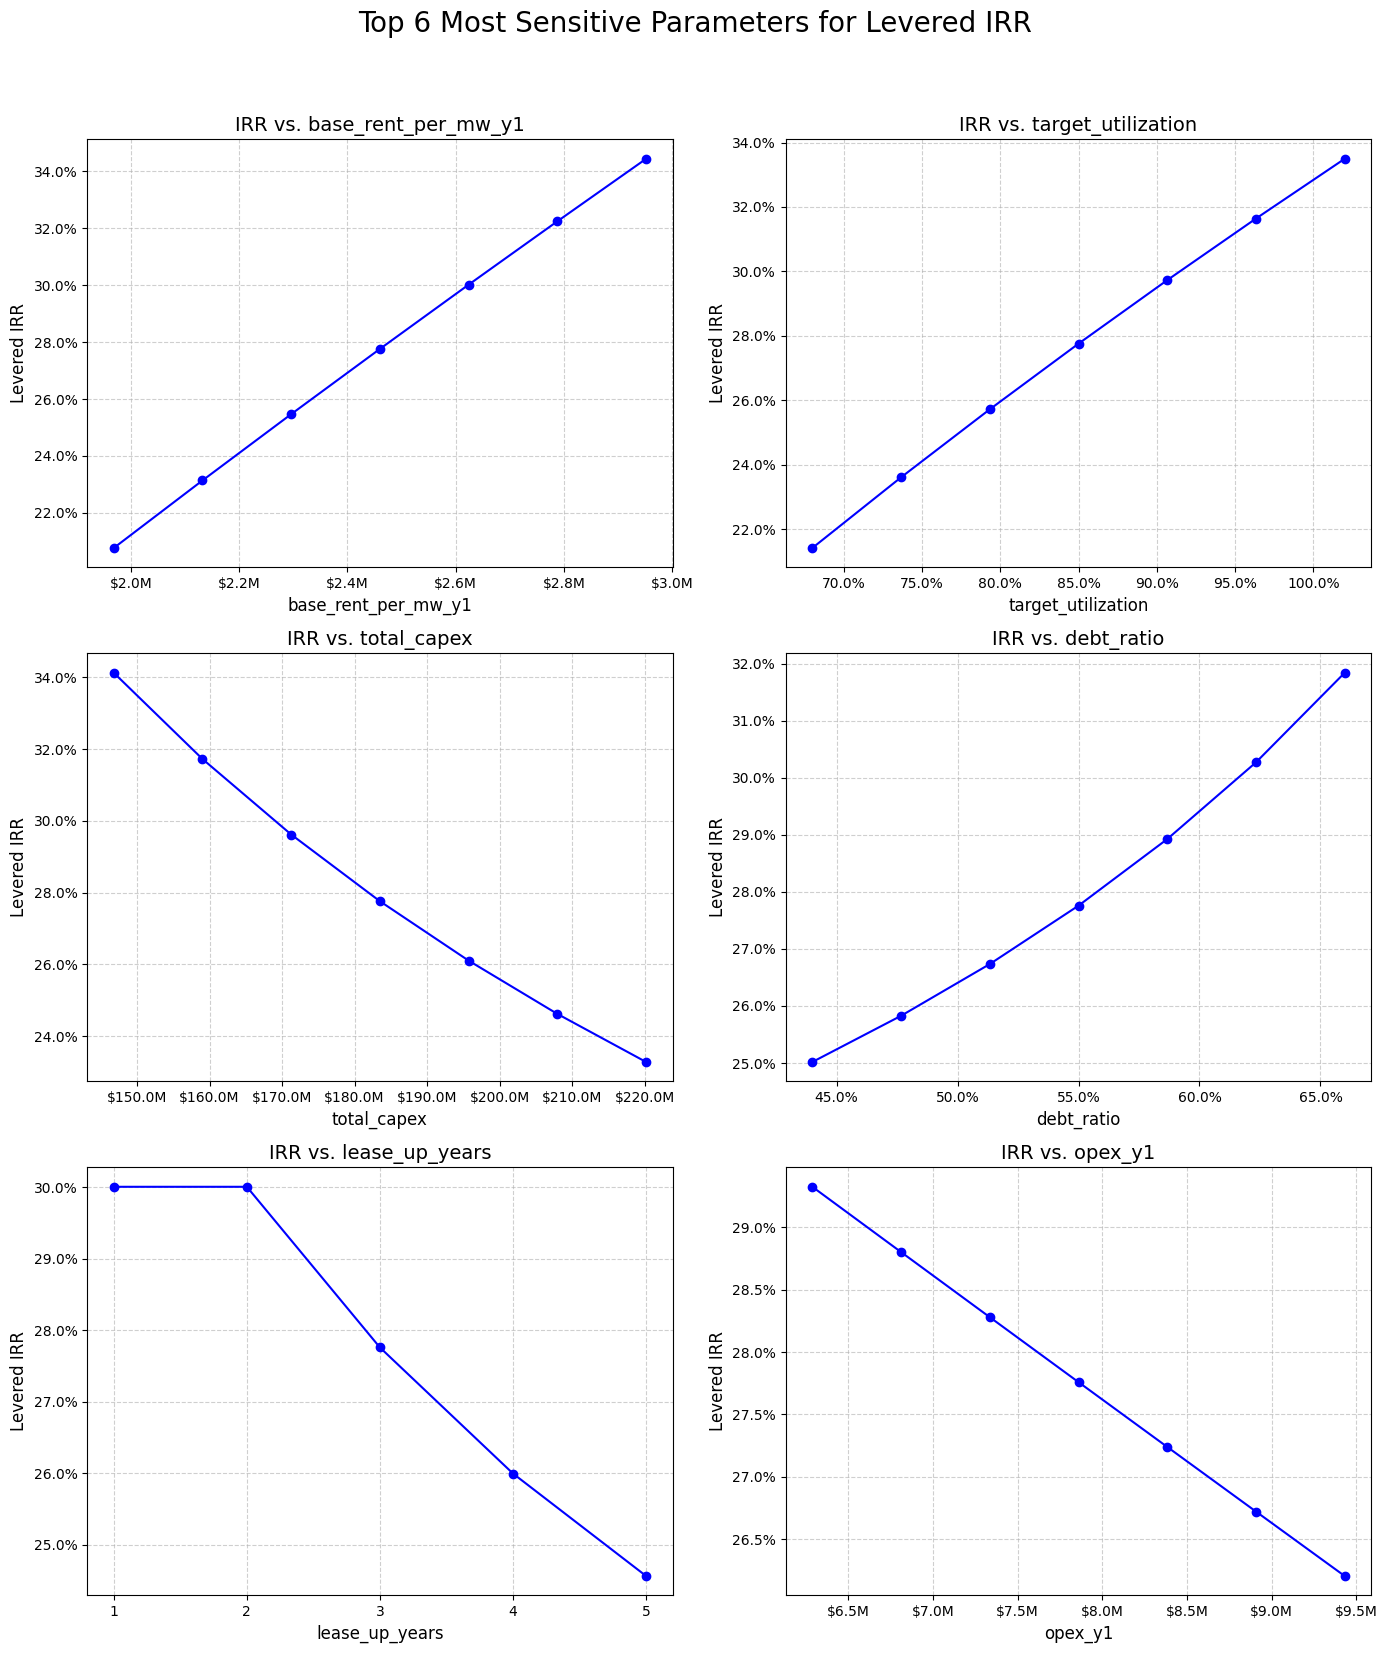

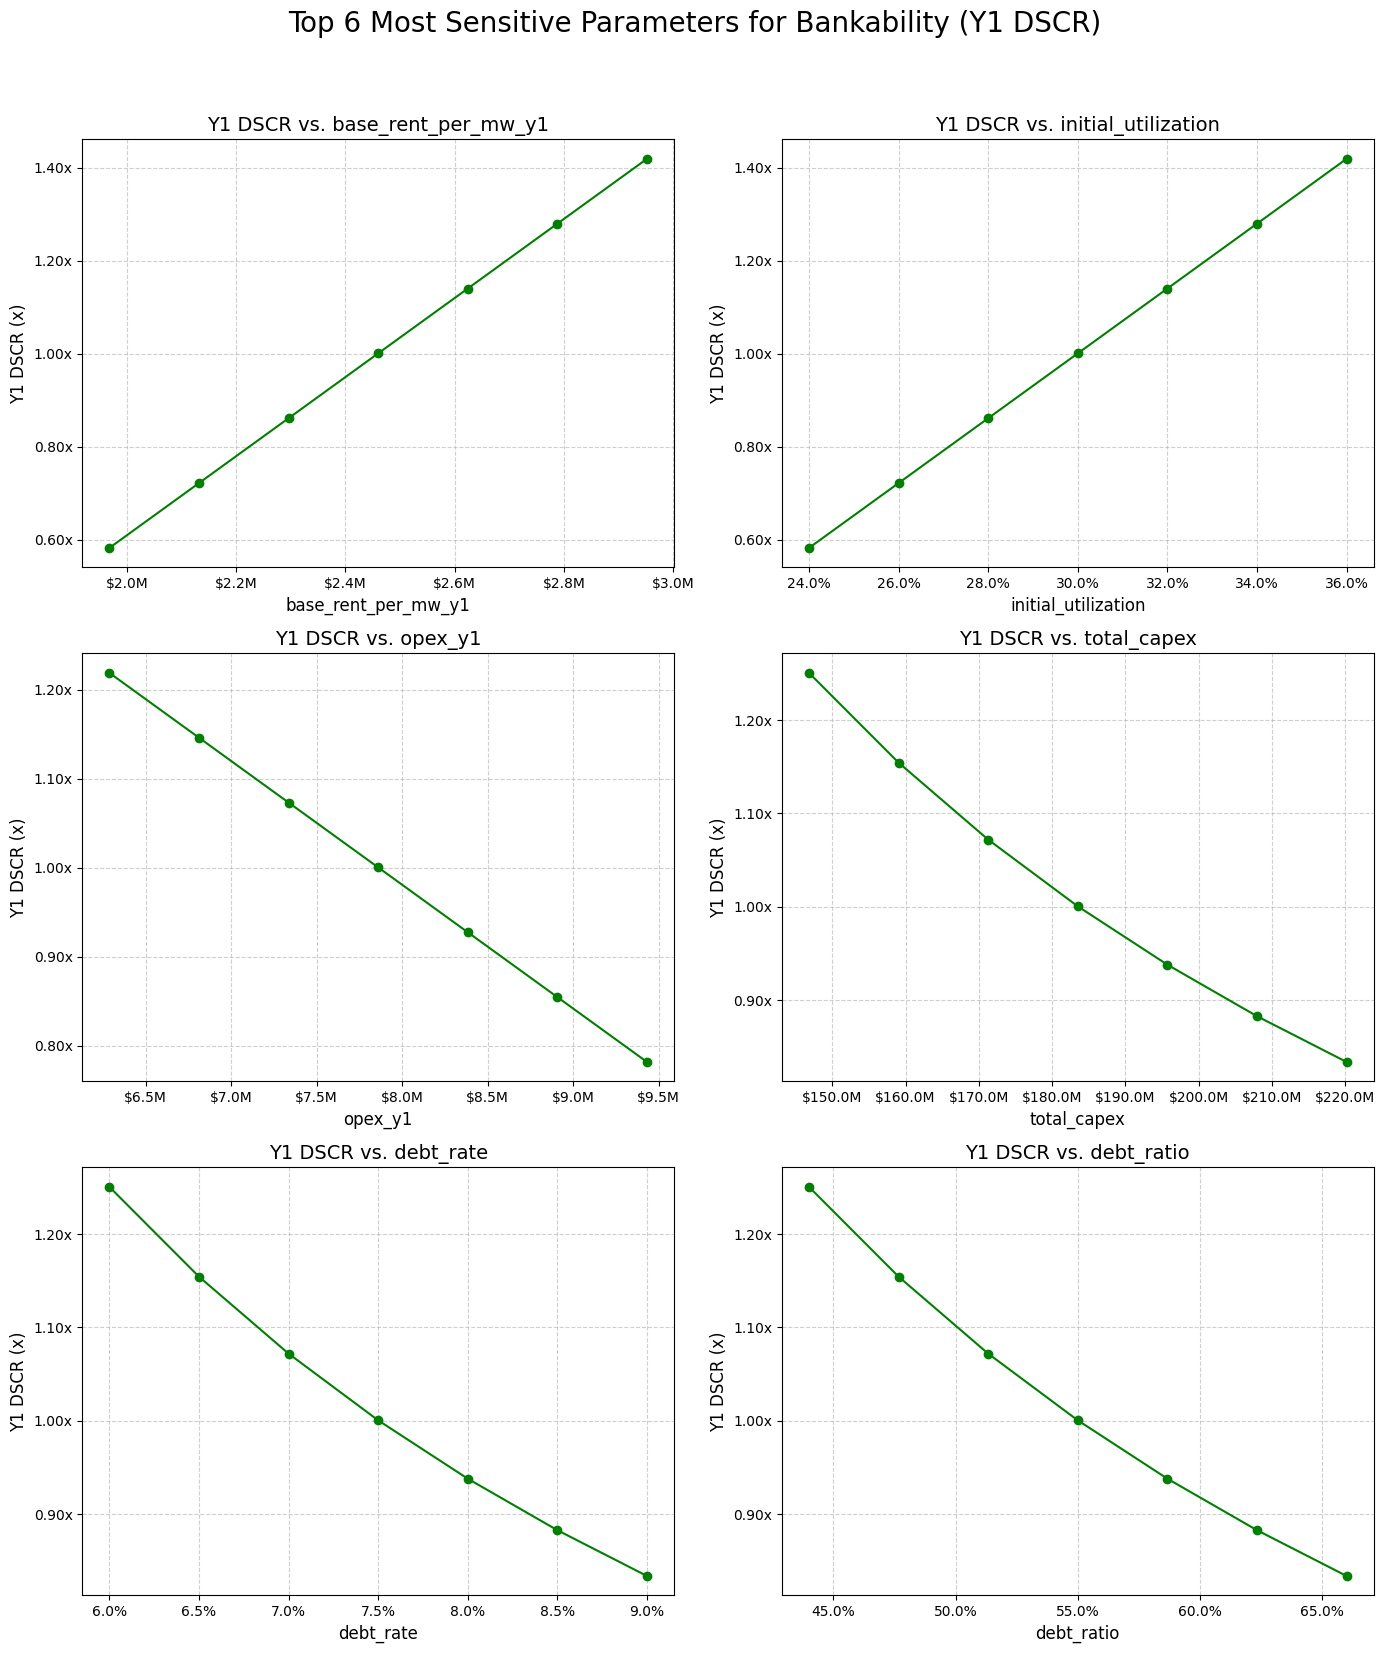

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter, PercentFormatter, MaxNLocator

print("\n" + "="*50)
print("   Step 3: Defining Comprehensive Sensitivity Analysis (IRR & DSCR)")
print("="*50)

def run_comprehensive_sensitivity():
    
    # --- 1. Define the Base Case (Scenario B) ---
    # Pull the solved "floor" rent from the baseline analysis in Cell 5
    try:
        SOLVED_BASE_RENT = baseline_summary_df.loc[baseline_summary_df['Scenario'] == 'B_Rural_Flex', 'Min Viable Rent ($/MW-yr)'].iloc[0]
    except (NameError, IndexError):
        print("Warning: 'baseline_summary_df' not found. Using placeholder rent $2.95M. Re-run Step 1.")
        SOLVED_BASE_RENT = 2_951_416 # Fallback rent from image_c5b7eb.png
        
    BASE_SCENARIO_CFG = SCENARIO_CONFIGS["B_Rural_Flex"]
    BASE_CASE_CFG = {
        **BASE_PARAMS, 
        **BASE_SCENARIO_CFG,
        "base_rent_per_mw_y1": SOLVED_BASE_RENT 
    }
    
    # Run model once to get the baseline IRR & DSCR for the chart title
    try:
        base_res = run_model(BASE_CASE_CFG)
        baseline_irr = base_res['levered_irr']
        baseline_dscr = base_res['series']['dscr'][0]
    except Exception as e:
        print(f"Error running baseline for sensitivity: {e}")
        baseline_irr = TARGET_IRR
        baseline_dscr = DSCR_RAMP[0]

    print(f"Running sensitivities around Scenario B Base Case:")
    print(f"  Base Rent: ${SOLVED_BASE_RENT:,.0f}/MW-yr")
    print(f"  Base IRR:  {baseline_irr:.2%}")
    print(f"  Base Y1 DSCR: {baseline_dscr:.2f}x")

    # --- 2. Define All Parameters to Sweep ---
    params_to_sweep = [
        'base_rent_per_mw_y1', 'total_capex', 'opex_y1', 
        'initial_utilization', 'target_utilization', 'lease_up_years',
        'rent_escalator', 'opex_escalator', 'service_revenue_pct',
        'capex_incentive_pct', 'renewables_uplift_pct', 'terminal_multiple',
        'debt_ratio', 'debt_rate', 'io_years'
    ]
    
    sensitivity_results = []
    plot_data_map = {}

    # --- 3. Run Sweeps ---
    print("Sweeping all 15 parameters...")
    for param in params_to_sweep:
        base_val = BASE_CASE_CFG.get(param, 0.0)
        
        # *** THIS IS THE FIX ***
        # Use an integer range for year-based parameters
        if param in ['lease_up_years', 'io_years']:
            sweep_values = np.arange(max(1, int(base_val) - 2), int(base_val) + 3) # e.g., [1, 2, 3, 4, 5]
        else:
            # Use a float range for all other parameters
            val_low, val_high = base_val * 0.8, base_val * 1.2
            
            # Handle 0% base values (like incentives)
            if base_val == 0:
                if param == 'capex_incentive_pct':
                    val_high = 0.10 # Sweep from 0% to 10%
                elif param == 'service_revenue_pct':
                    val_high = 0.05 # Sweep from 0% to 5%
                elif param == 'renewables_uplift_pct':
                     val_high = 0.02 # Sweep from 0% to 2%
                elif val_low == 0 and val_high == 0:
                     val_high = 0.1 # Generic sweep for other 0 values
            
            sweep_values = np.linspace(val_low, val_high, 7) # 7 data points per plot
        
        param_results = []
        for val in sweep_values:
            cfg = BASE_CASE_CFG.copy()
            cfg[param] = val # val is already the correct type (int or float)

            res = run_model(cfg)
            param_results.append({
                "x": val, 
                "irr": res["levered_irr"],
                "dscr_y1": res["series"]["dscr"][0]
            })
        
        results_df = pd.DataFrame(param_results)
        plot_data_map[param] = results_df
        
        # Calculate the range of impact
        irr_sensitivity = results_df["irr"].max() - results_df["irr"].min()
        dscr_sensitivity = results_df["dscr_y1"].max() - results_df["dscr_y1"].min()
        
        sensitivity_results.append({
            "Parameter": param, 
            "IRR_Impact": irr_sensitivity, 
            "DSCR_Impact": dscr_sensitivity
        })

    # --- 4. Rank and Plot Results ---
    print("Sweep complete. Generating rankings and plots...")
    
    df_sens = pd.DataFrame(sensitivity_results).set_index("Parameter")
    
    # Get Top 6 for each
    top_6_irr = df_sens.nlargest(6, "IRR_Impact").index.tolist()
    top_6_dscr = df_sens.nlargest(6, "DSCR_Impact").index.tolist()

    print("\n--- Sensitivity Rankings (Full List) ---")
    display(df_sens.sort_values("IRR_Impact", ascending=False).style.format({
        "IRR_Impact": "{:.2%}", "DSCR_Impact": "{:.2f}x"
    }))

    # --- Figure 1: IRR Sensitivity ---
    fig1, axs1 = plt.subplots(3, 2, figsize=(14, 16))
    fig1.suptitle("Top 6 Most Sensitive Parameters for Levered IRR", fontsize=20, y=1.03)
    
    for i, param in enumerate(top_6_irr):
        ax = axs1.flat[i]
        data = plot_data_map[param]
        ax.plot(data["x"], data["irr"], marker='o', c='blue')
        ax.set_title(f"IRR vs. {param}", fontsize=14)
        ax.set_ylabel("Levered IRR", fontsize=12)
        ax.set_xlabel(param, fontsize=12)
        ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=1))
        
        if param in ['lease_up_years', 'io_years']:
            ax.xaxis.set_major_locator(MaxNLocator(integer=True)) # Force integer x-axis ticks
        elif data["x"].max() > 10000: 
            ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x/1e6:,.1f}M'))
        elif data["x"].max() > 5: 
            ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x:,.1f}x'))
        elif data["x"].max() >= 0.01: 
            ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=1))
            
        ax.grid(True, linestyle='--', alpha=0.6)
        
    plt.tight_layout()
    plt.show()

    # --- Figure 2: DSCR Sensitivity ---
    fig2, axs2 = plt.subplots(3, 2, figsize=(14, 16))
    fig2.suptitle("Top 6 Most Sensitive Parameters for Bankability (Y1 DSCR)", fontsize=20, y=1.03)

    for i, param in enumerate(top_6_dscr):
        ax = axs2.flat[i]
        data = plot_data_map[param]
        ax.plot(data["x"], data["dscr_y1"], marker='o', c='green')
        ax.set_title(f"Y1 DSCR vs. {param}", fontsize=14)
        ax.set_ylabel("Y1 DSCR (x)", fontsize=12)
        ax.set_xlabel(param, fontsize=12)
        ax.yaxis.set_major_formatter(FuncFormatter(lambda y, p: f'{y:.2f}x'))
        
        if param in ['lease_up_years', 'io_years']:
            ax.xaxis.set_major_locator(MaxNLocator(integer=True)) # Force integer x-axis ticks
        elif data["x"].max() > 10000: 
            ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x/1e6:,.1f}M'))
        elif data["x"].max() > 5: 
            ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x:,.1f}x'))
        elif data["x"].max() >= 0.01: 
            ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=1))
            
        ax.grid(True, linestyle='--', alpha=0.6)
        
    plt.tight_layout()
    plt.show()

# --- Run the analysis ---
run_comprehensive_sensitivity()